## Our goal is to create a model that can take a piece of text as the input, and determine the emotion
## of the text, and return this emotion label for us.

### To do this, we'll be fine tuning an Xlnet model.

We have a labeled data set of a number of different sentences and their emotion label.

We'll be providing this to the model so that it can learn these associations from our data.

We'll then have a custom fine tuned language model of our own.

So let's get started.

In [8]:
import pandas as pd
import numpy as np
from cleantext import clean
from transformers import XLNetTokenizer, XLNetForSequenceClassification, TrainingArguments, Trainer, pipeline
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import datasets
import evaluate
import random
import re

### PRE PROCESSING OUR DATA

In [9]:
data_train = pd.read_csv('./emotions_data/emotion-labels-train.csv')
data_test = pd.read_csv('./emotions_data/emotion-labels-test.csv')
data_val = pd.read_csv('./emotions_data/emotion-labels-val.csv')

In [10]:
data_train.head()

,text,label
0,Just got back from seeing @GaryDelaney in Burs...,joy
1,Oh dear an evening of absolute hilarity I don'...,joy
2,Been waiting all week for this game ❤️❤️❤️ #ch...,joy
3,"@gardiner_love : Thank you so much, Gloria! Yo...",joy
4,I feel so blessed to work with the family that...,joy


In [11]:
#Let's concatenate the train test and validation sets together for now so that we can clean them up all in one go.
data = pd.concat([data_train, data_test, data_val], ignore_index=True)

In [12]:
# We can then see we have some emojis in the text. We want to remove these.
# We also want to remove any punctuation from this text.
data['text_clean'] = data['text'].apply(lambda x: clean(x, no_emoji=True))


In [13]:
data['text_clean'] = data['text_clean'].apply(lambda x : re.sub('@[^\s]+', '', x))

In [15]:
data.head(20)

,text,label,text_clean
0,Just got back from seeing @GaryDelaney in Burs...,joy,just got back from seeing in burslem. amazing...
1,Oh dear an evening of absolute hilarity I don'...,joy,oh dear an evening of absolute hilarity i don'...
2,Been waiting all week for this game ❤️❤️❤️ #ch...,joy,been waiting all week for this game #cheer #fr...
3,"@gardiner_love : Thank you so much, Gloria! Yo...",joy,": thank you so much, gloria! you're so sweet,..."
4,I feel so blessed to work with the family that...,joy,i feel so blessed to work with the family that...
5,"Today I reached 1000 subscribers on YT!! , #go...",joy,"today i reached 1000 subscribers on yt!! , #go..."
6,"@Singaholic121 Good morning, love! Happy first...",joy,"good morning, love! happy first day of fall. ..."
7,#BridgetJonesBaby is the best thing I've seen ...,joy,#bridgetjonesbaby is the best thing i've seen ...
8,Just got back from seeing @GaryDelaney in Burs...,joy,just got back from seeing in burslem. amazing...
9,@IndyMN I thought the holidays could not get a...,joy,i thought the holidays could not get any more...


Let's now look to the labels.

We can print these out to check how many pieces of text we have associated with each of the labels.

We'll take the label column and then do the value counts and plot it as a bar chart.



<Axes: xlabel='label'>

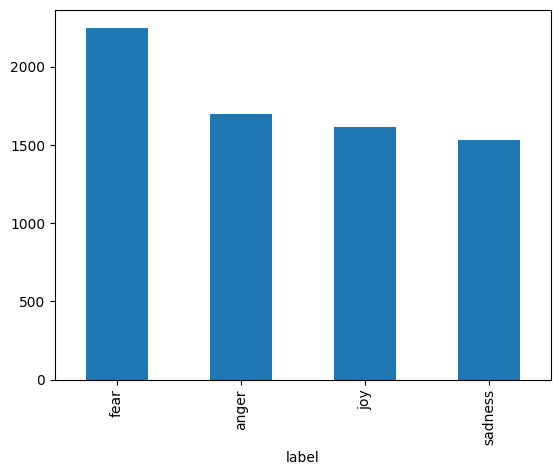

In [16]:
data['label'].value_counts().plot(kind="bar")

So you can see we've got four emotion classifications here.

Fear anger, joy and sadness.

#### We can also see this as an unbalanced data set.
#### We have a lot more occurrences of text with the label fear compared to sadness, so we want to make
#### sure we have an equal number of pieces of text for each of our labels.

#####  BELOW CODE EXPLANATION

So the first thing we can do is take our data and group it by the label.

We then want to create a new data frame.

And from this we're going to sample based on the size of the number of rows in the labels.

We'll take the minimum and then we'll reset the index where drop equals true.

Essentially what this is doing is taking our data frame, grouping it by the label, finding the group

with the least number of rows.

So in this case, that would be sadness.

And then using that minimum value to sample from all the other labels.

In [18]:
g = data.groupby('label')
data = pd.DataFrame(g.apply(lambda x : x.sample(g.size().min()).reset_index(drop =True)))

<Axes: xlabel='label'>

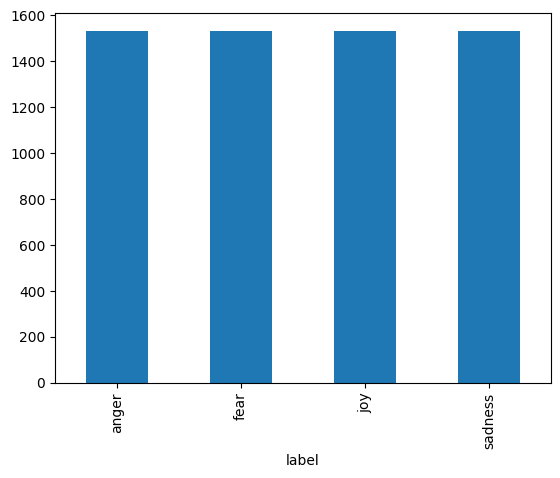

In [19]:
data['label'].value_counts().plot(kind="bar")

And we can see we now have an equal number of rows per each label.

We also want to convert our labels into an integer.

So we can use Labelencoder dot fittransform over our label column.

In [20]:
data['label_int'] = LabelEncoder().fit_transform(data['label'])

In [22]:
NUM_LABELS = 4

#### The final step in pre-processing our text is creating the training and test data.

In [24]:
#So first we'll create our train split and our test split using the train test split function from sklearn.
#We also want to create a validation set.
#So we'll split our training dataset again and put aside 10% for the validation

train_split, test_split = train_test_split(data, train_size = 0.8)
train_split, validation_split = train_test_split(data, train_size = 0.9)

Let's then print out the lengths to see how many rows we have in each of our splits.
So you can see most of our data is going to training some of it to testing.
And then we've left a small sample for validation.

In [26]:
print(len(train_split))
print(len(test_split))
print(len(validation_split))

5518
1227
614


We then want to format our data into a data set dictionary.

We also want to remove any columns that we aren't going to be using.

So first let's create our train DF.

In [27]:
train_df = pd.DataFrame ({
    "label" : train_split.label_int.values,
    "text" : train_split.text_clean.values
})
train_df

,label,text
0,2,punchline king is back! #bright city lights
1,3,lol senior year we would get early dismal for...
2,2,a lifetime of laughter at the expense of the d...
3,0,we about to get shit on by the wrath of winte...
4,2,a hearty thank you to you all for joining in t...
...,...,...
5513,2,watching the ny phil webcast. something missin...
5514,3,haha bro she's sadly married man
5515,1,"heads melted, very tired but can't sleep."
5516,2,loving #pitch so far !! #chills


In [28]:
test_df = pd.DataFrame ({
    "label" : test_split.label_int.values,
    "text" : test_split.text_clean.values
})
test_df

,label,text
0,3,i am often disturbed by what some people find ...
1,3,need advice on how to get out of this rut!!!! ...
2,1,rojo is awful
3,2,very pleasing ty!
4,1,georgia tech's secondary is as soft as a marsh...
...,...,...
1222,0,did you even give out any pizzas ? serious fa...
1223,2,"while i was walking, a little boy in a red shi..."
1224,2,watch this amazing live.ly broadcast by #live...
1225,0,how did that chop feel? you still feel th...


So from our test data set we'll be taking the label integers and our clean text.

We then want to format these into a data set dictionary.

In [29]:
train_df = datasets.Dataset.from_dict(train_df)
test_df = datasets.Dataset.from_dict(test_df)

In [30]:
#And from here we can create our data set dict.
dataset_dict = datasets.DatasetDict({"train": train_df, "test":test_df})

In [31]:
dataset_dict

DatasetDict({
    train: Dataset({
        features: ['label', 'text'],
        num_rows: 5518
    })
    test: Dataset({
        features: ['label', 'text'],
        num_rows: 1227
    })
})

### So we have our data set dictionary split into train and test both with the features label and text.

### We're now ready to create our embeddings.

## CREATE EMBEDDINGS
#So to create our embeddings, the first step is to load our tokenizer.

In [32]:
tokenizer = XLNetTokenizer.from_pretrained("xlnet-base-cased")

In [33]:
def tokenize_function(examples):
    return tokenizer(examples["text"], padding= "max_length", max_length =128, truncation = True)

In [34]:
tokenized_datasets = dataset_dict.map(tokenize_function, batched =True)

Map:   0%|          | 0/5518 [00:00<?, ? examples/s]

Map:   0%|          | 0/1227 [00:00<?, ? examples/s]

In [35]:
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['label', 'text', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5518
    })
    test: Dataset({
        features: ['label', 'text', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1227
    })
})

Once that is run we can check our tokenized data sets.

We can see we've been given a dataset dictionary with the features the label, the text, the input

IDs, the token type IDs, and the attention mask.

Let's go through and check some of these embeddings.

In [36]:
print(tokenized_datasets['train']['text'][0])

punchline king is back!  #bright city lights


In [37]:
print(tokenized_datasets['train']['input_ids'][0])

[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 8977, 814, 3351, 27, 126, 136, 17, 7967, 508, 3860, 285, 4896, 4, 3]


We'll print tokenized datasets from our train dataset.

Will take the text and we'll just take the first Occurrence.

In [38]:
tokenizer.decode(5)

'<pad>'

Let's then check the token type IDs.

So for the padded tokens we can see these have been given a token type ID of three.

Our sentence has been given a token type of zero, and one of the special tokens has been given a token

type of two.

You can now see how this helps the model distinguish what different things are, what different tokens

are within the text that it's been fed 

In [39]:
print(tokenized_datasets['train']['token_type_ids'][0])

[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2]


We can see all the Pad tokens have been given a value of zero because the model doesn't need to pay

attention to these.

The only thing it needs to pay attention to is where the ones are in the attention mask.

So this is our sentence and our special tokens.

In [40]:
print(tokenized_datasets['train']['attention_mask'][0])

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


### Let's just take a sample of the tokenized data set for a training demonstration, or it will take quite
### a while to run.

In [43]:
small_train_tokenized_dataset = tokenized_datasets["train"].shuffle(seed=42).select(range(100))
small_test_tokenized_dataset = tokenized_datasets["test"].shuffle(seed=42).select(range(100))

## we are now ready to fine tune our model

In [44]:
# Fine tuning a model is made easy by the hugging face package.
model = XLNetForSequenceClassification.from_pretrained('xlnet-base-cased',
                                                      num_labels=NUM_LABELS,
                                                      id2label={0: 'anger', 1: 'fear', 2: 'joy', 3: 'sadness'}) #We then want to provide the id to label, which is essentially the mapping of the numeric values to their label representation using the evaluate package.

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


pytorch_model.bin:   0%|          | 0.00/467M [00:00<?, ?B/s]

C:\Users\moham\anaconda3\envs\llms_course_env\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\moham\.cache\huggingface\hub\models--xlnet-base-cased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Some weights of XLNetForSequenceClassification were not initialized from the model checkpoint at xlnet-base

We can specify which measure of accuracy we want the model to evaluate when it's training.

So we'll specify our metric and then use evaluate dot load.

In [45]:
metric = evaluate.load("accuracy")

We then need to define a function to compute the accuracy.

So we'll define our compute metrics.

And from this we take the logits and the labels.

We can then use this to compute our predictions.

So we'll use np.argmax over our logits.

And then we want to return our metric dot compute where our predictions equals our predictions.

And our references are our labels.

This will compute the accuracy for us.

In [52]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

The next thing we need to do for preparing to train our model is specify a directory to save our training

hyperparameters.

You can also use this function to add your custom hyperparameters.

You'll specify the output directory of where to save your hyperparameters.

We also want to specify that the accuracy is to be evaluated at each epoch.

So we can add evaluation strategy equals epoch.

And we can also specify the number of training epochs.

Here we'll specify three.

In [53]:
training_args =TrainingArguments(output_dir = "test_trainer", eval_strategy="epoch", num_train_epochs = 3)

## So now we've set up our training arguments and have a method to compute the accuracy of our training.
## We're ready to set up our trainer so we can use the trainer function from hugging face.

In [54]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset = small_train_tokenized_dataset,
    eval_dataset = small_test_tokenized_dataset,
    compute_metrics= compute_metrics
)

We're ready to set up our trainer so we can use the trainer function from hugging face.

We want to specify our model.

And then we need to provide our training arguments.

Our train dataset and our evaluation Data set and our compute metrics function.

We can then run Trainer.train.

This will train our model based on all the arguments we've set up in our trainer function.

In [55]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,No log,1.448964,0.300000
2,No log,1.457866,0.270000
3,No log,1.430959,0.290000


TrainOutput(global_step=39, training_loss=1.255920605781751, metrics={'train_runtime': 119.9569, 'train_samples_per_second': 2.501, 'train_steps_per_second': 0.325, 'total_flos': 21366375321600.0, 'train_loss': 1.255920605781751, 'epoch': 3.0})

#### We can see that at each epoch the accuracy is being evaluated, and once this is finished running,
#### we have successfully fine tuned our Xlnet model based on our custom data.
#### The last thing to do is now just evaluate the performance of this model.

## . Evaluating our model

In [57]:
#Again, the hugging face package makes it easy to evaluate this model.
trainer.evaluate()

{'eval_loss': 1.4309587478637695,
 'eval_accuracy': 0.29,
 'eval_runtime': 9.0744,
 'eval_samples_per_second': 11.02,
 'eval_steps_per_second': 1.433,
 'epoch': 3.0}

In [59]:
#Let's say we're happy with this and we now want to save our custom model.
model.save_pretrained("fine_tuned_model") # FOLDER NMAE WHERE OUR FINE TUNED MODEL IS SAVED

In [60]:
fine_tuned_model = XLNetForSequenceClassification.from_pretrained("fine_tuned_model")

We then want to use the pipeline function with our fine tuned model.

So we're creating a pipeline.

and the task is text classification.

Our model is our fine tuned model and our tokenizer is our tokenizer.

In [61]:
clf = pipeline("text-classification", fine_tuned_model, tokenizer= tokenizer)

Device set to use cpu


Let's now run this pipeline over some samples from our validation dataset.
First, we'll just specify a random number to take a random row from our dataset.
We then want to print the text from this row so that we can inspect it.
And then to get our answer.
So our classification from the model will use our CLF pipeline we've created over the text.
And we'll specify top k equals none.
So we can see the prediction scores for each of the labels that we've trained.
We can then print this out.
So you can see it's been printed our sentence and the associated labels and their scores.

In [65]:
rand_int= random.randint(0, len(validation_split))
print(validation_split['text_clean'][rand_int])
answer = clf(validation_split['text_clean'][rand_int], top_k =None)
print(answer)

 ka- like the start of cake and then like saying c - if that makes sense
[{'label': 'joy', 'score': 0.3918018639087677}, {'label': 'fear', 'score': 0.2258613556623459}, {'label': 'anger', 'score': 0.20345985889434814}, {'label': 'sadness', 'score': 0.17887690663337708}]


And now you're able to successfully fine tune a model for your specific task using your own custom data.